# 🚀 Prediksi Workload: Tahap 1 - Preprocessing & Feature Engineering
Notebook ini mendemonstrasikan tahap awal data science pipeline: pembersihan data, *resampling*, normalisasi, dan pembuatan tensor 3D untuk model sequence.
Data akan disimpan pada akhirnya agar dapat dimuat oleh model-model secara independen.

## Latar Belakang & Evaluasi Dataset
Data mentah jarang siap pakai. Tahap ini meliputi penanganan data hilang, duplikasi, outlier, dan standardisasi.
Membandingkan deret waktu mentah vs agregasi 2-detik untuk mengurangi fluktuasi.

### Tabel 2: Worldcup98 dataset (Referensi Imdoukh et al.)
| Ref. | Dataset | Size | Usage |
|---|---|---|---|
| S1 | Workload per second | 5,244,199 | Evaluation |
| S2 | Workload per second | 2,255,274 | Evaluation |
| M1 | Workload per minute | 87,710 | Training |
| M2 | Workload per minute | 37,590 | Evaluation |

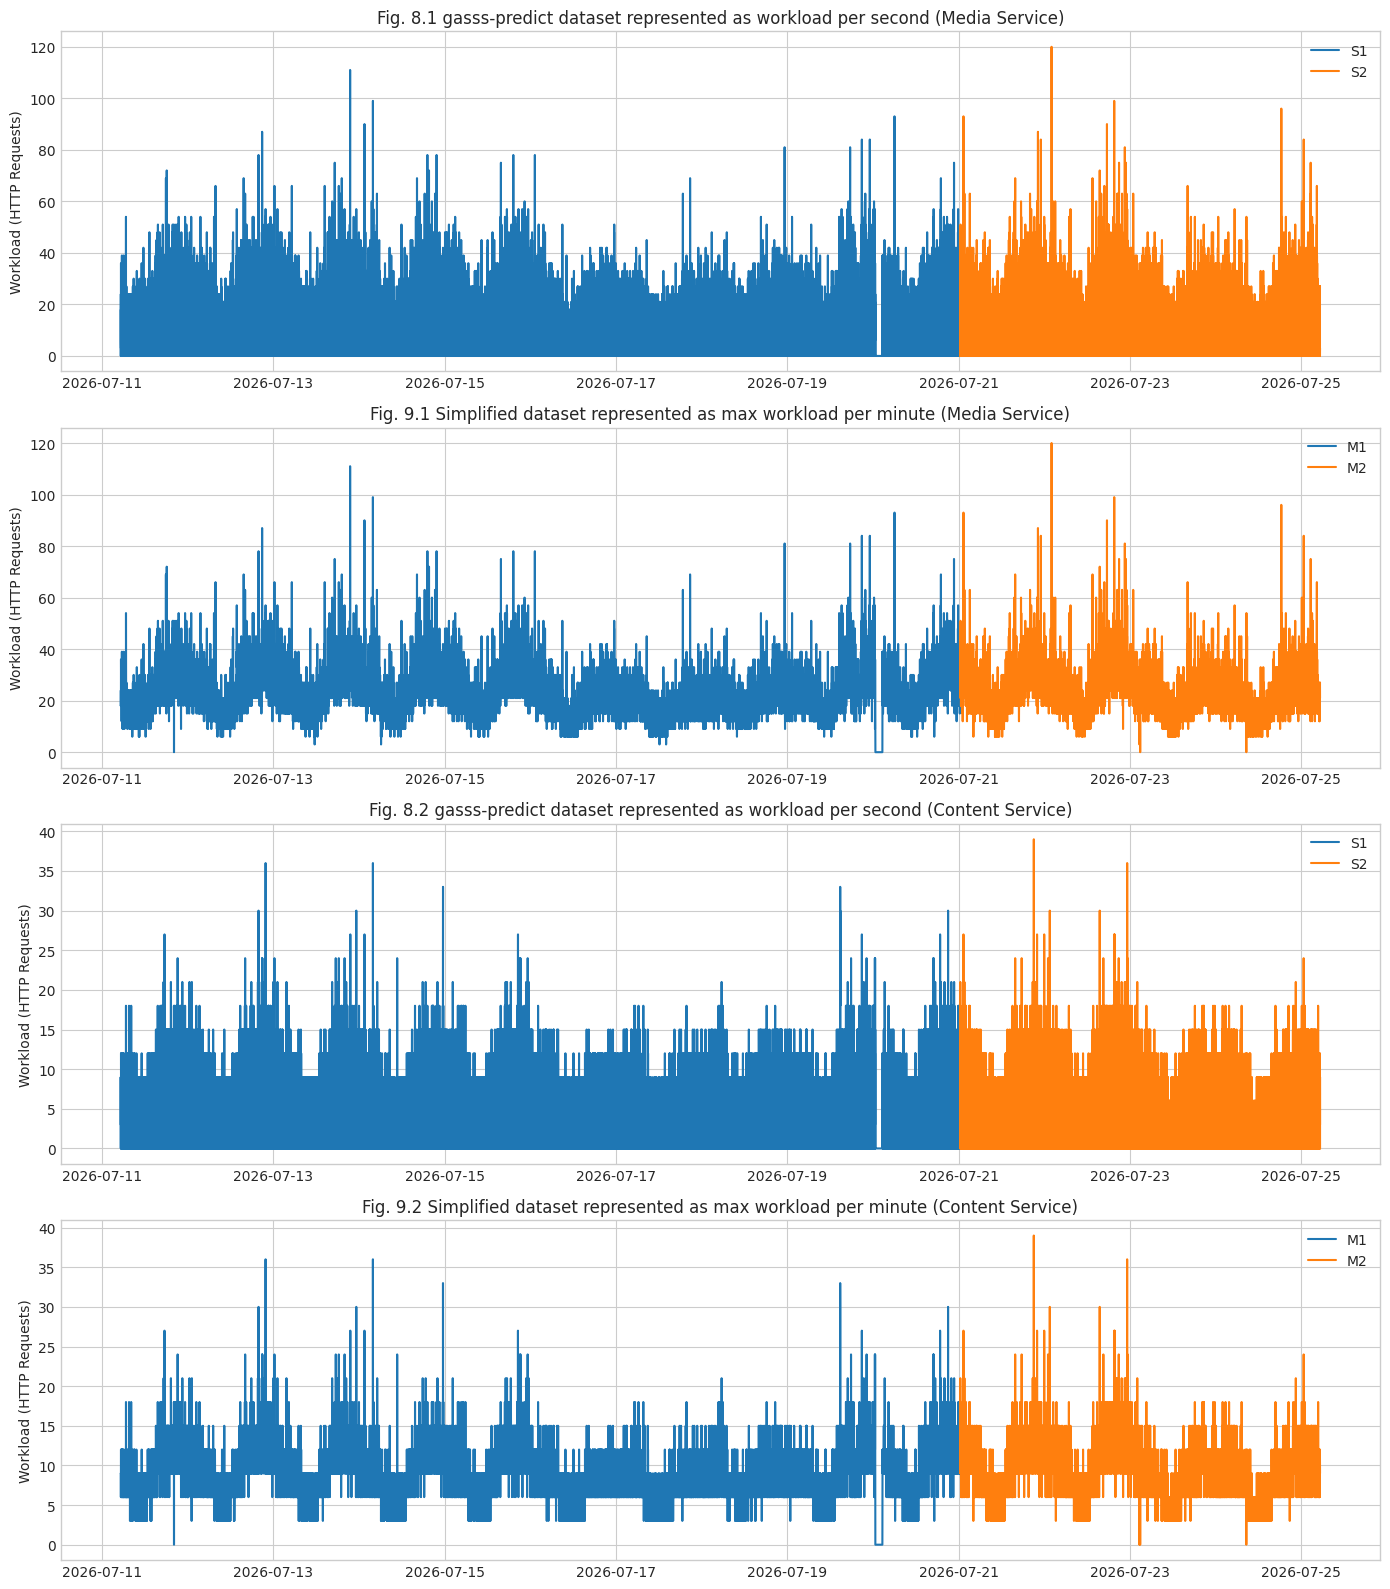

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# 1. Menangani data hilang, menghapus duplikasi
df_raw = pd.read_csv('all_merged_metrics.csv')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], unit='s')
df_raw.set_index('timestamp', inplace=True)
df_raw.sort_index(inplace=True)
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]
df_raw.interpolate(method='time', inplace=True)
df_raw.bfill(inplace=True)

# 2. Resampling 1 Menit (mengambil nilai maksimum) sesuai Imdoukh
df_resampled = df_raw.resample('1min').max().dropna()

fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=False)

split_raw = int(len(df_raw) * 0.70)
split_res = int(len(df_resampled) * 0.70)

# Plot 1: Raw RPS Media
axes[0].plot(df_raw.index[:split_raw], df_raw['rps_media'].iloc[:split_raw], label='S1', color='tab:blue')
axes[0].plot(df_raw.index[split_raw:], df_raw['rps_media'].iloc[split_raw:], label='S2', color='tab:orange')
axes[0].set_title('Fig. 8.1 gasss-predict dataset represented as workload per second (Media Service)', fontsize=12)
axes[0].set_ylabel('Workload (HTTP Requests)')
axes[0].legend()

# Plot 2: Resampled RPS Media
axes[1].plot(df_resampled.index[:split_res], df_resampled['rps_media'].iloc[:split_res], label='M1', color='tab:blue')
axes[1].plot(df_resampled.index[split_res:], df_resampled['rps_media'].iloc[split_res:], label='M2', color='tab:orange')
axes[1].set_title('Fig. 9.1 Simplified dataset represented as max workload per minute (Media Service)', fontsize=12)
axes[1].set_ylabel('Workload (HTTP Requests)')
axes[1].legend()

# Plot 3: Raw RPS Content
axes[2].plot(df_raw.index[:split_raw], df_raw['rps_content'].iloc[:split_raw], label='S1', color='tab:blue')
axes[2].plot(df_raw.index[split_raw:], df_raw['rps_content'].iloc[split_raw:], label='S2', color='tab:orange')
axes[2].set_title('Fig. 8.2 gasss-predict dataset represented as workload per second (Content Service)', fontsize=12)
axes[2].set_ylabel('Workload (HTTP Requests)')
axes[2].legend()

# Plot 4: Resampled RPS Content
axes[3].plot(df_resampled.index[:split_res], df_resampled['rps_content'].iloc[:split_res], label='M1', color='tab:blue')
axes[3].plot(df_resampled.index[split_res:], df_resampled['rps_content'].iloc[split_res:], label='M2', color='tab:orange')
axes[3].set_title('Fig. 9.2 Simplified dataset represented as max workload per minute (Content Service)', fontsize=12)
axes[3].set_ylabel('Workload (HTTP Requests)')
axes[3].legend()

plt.tight_layout()
plt.show()

# 3. Menangani Outlier & Normalisasi
for col in ['rps_media', 'rps_content']:
    Q1 = df_resampled[col].quantile(0.25)
    Q3 = df_resampled[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    df_resampled[col] = np.where(df_resampled[col] > upper_bound, upper_bound, df_resampled[col])

rps_scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = rps_scaler.fit_transform(df_resampled[['rps_media', 'rps_content']])
df_scaled = pd.DataFrame(scaled_data, columns=['rps_media', 'rps_content'], index=df_resampled.index)


## Feature Engineering
Mengekstrak fitur *Time Steps*, menggunakan 120 time steps ke belakang sebagai memory memori penuh.

In [20]:
features = ['rps_media', 'rps_content']
df_features = df_scaled[features]

def create_dataset(dataset, time_steps=1):
    X, Y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), :])
        Y.append(dataset[i + time_steps, :2])
    return np.array(X), np.array(Y)

TIME_STEPS = 10
X, y = create_dataset(df_features.values, TIME_STEPS)
print(f"Total Sampel Data 3D: {X.shape[0]} | Shape X Tensor: {X.shape} | Shape Y Tensor: {y.shape}")

# Split Dataset (70% Train, 30% Test, lalu 10% dari Train untuk Validation)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.30, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.10, shuffle=False)

# Simpan data ke disk agar model bisa mengaksesnya
np.savez_compressed('processed_data.npz', 
                    X_train=X_train, y_train=y_train, 
                    X_val=X_val, y_val=y_val, 
                    X_test=X_test, y_test=y_test)
with open('rps_scaler.pkl', 'wb') as f:

    pickle.dump(rps_scaler, f)
print("Berhasil menyimpan data latih dan scaler.")


Total Sampel Data 3D: 20148 | Shape X Tensor: (20148, 10, 2) | Shape Y Tensor: (20148, 2)
Berhasil menyimpan data latih dan scaler.
